<a href="https://colab.research.google.com/github/Adeel213/Deep-learning/blob/main/Deep_Learning(Horse_vs_Human).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!wget 'https://storage.googleapis.com/download.tensorflow.org/data/horse-or-human.zip'

--2026-09-08 14:52:10--  https://storage.googleapis.com/download.tensorflow.org/data/horse-or-human.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 34.144.170.27, 104.154.125.27, 34.3.1.27, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|34.144.170.27|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 149574867 (143M) [application/zip]
Saving to: ‘horse-or-human.zip’

horse-or-human.zip  100%[===================>] 142.65M  17.7MB/s    in 8.9s    

2026-09-08 14:52:19 (16.0 MB/s) - ‘horse-or-human.zip’ saved [149574867/149574867]



In [ ]:
!wget 'https://storage.googleapis.com/download.tensorflow.org/data/validation-horse-or-human.zip'

--2026-09-08 15:07:13--  https://storage.googleapis.com/download.tensorflow.org/data/validation-horse-or-human.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.12.207, 172.217.194.207, 74.125.24.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.12.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11480187 (11M) [application/zip]
Saving to: ‘validation-horse-or-human.zip’

validation-horse-or 100%[===================>]  10.95M  6.02MB/s    in 1.8s    

2026-09-08 15:07:15 (6.02 MB/s) - ‘validation-horse-or-human.zip’ saved [11480187/11480187]



In [ ]:
!unzip '/content/validation-horse-or-human.zip' -d '/content/validation-horse-or-human'

Archive:  /content/validation-horse-or-human.zip
  inflating: /content/validation-horse-or-human/horses/horse1-000.png  
  inflating: /content/validation-horse-or-human/horses/horse1-105.png  
  inflating: /content/validation-horse-or-human/horses/horse1-122.png  
  inflating: /content/validation-horse-or-human/horses/horse1-127.png  
  inflating: /content/validation-horse-or-human/horses/horse1-170.png  
  inflating: /content/validation-horse-or-human/horses/horse1-204.png  
  inflating: /content/validation-horse-or-human/horses/horse1-224.png  
  inflating: /content/validation-horse-or-human/horses/horse1-241.png  
  inflating: /content/validation-horse-or-human/horses/horse1-264.png  
  inflating: /content/validation-horse-or-human/horses/horse1-276.png  
  inflating: /content/validation-horse-or-human/horses/horse1-298.png  
  inflating: /content/validation-horse-or-human/horses/horse1-335.png  
  inflating: /content/validation-horse-or-human/horses/horse1-384.png  
  inflating: /c

In [ ]:
!unzip '/content/horse-or-human.zip' -d '/content/horse-or-human'

Archive:  /content/horse-or-human.zip
  inflating: /content/horse-or-human/horses/horse01-0.png  
  inflating: /content/horse-or-human/horses/horse01-1.png  
  inflating: /content/horse-or-human/horses/horse01-2.png  
  inflating: /content/horse-or-human/horses/horse01-3.png  
  inflating: /content/horse-or-human/horses/horse01-4.png  
  inflating: /content/horse-or-human/horses/horse01-5.png  
  inflating: /content/horse-or-human/horses/horse01-6.png  
  inflating: /content/horse-or-human/horses/horse01-7.png  
  inflating: /content/horse-or-human/horses/horse01-8.png  
  inflating: /content/horse-or-human/horses/horse01-9.png  
  inflating: /content/horse-or-human/horses/horse02-0.png  
  inflating: /content/horse-or-human/horses/horse02-1.png  
  inflating: /content/horse-or-human/horses/horse02-2.png  
  inflating: /content/horse-or-human/horses/horse02-3.png  
  inflating: /content/horse-or-human/horses/horse02-4.png  
  inflating: /content/horse-or-human/horses/horse02-5.png  
  

In [ ]:
import os
import random
import numpy as np

# Plotting and dealing with images
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
VAL_DIR = 'validation-horse-or-human'
print(f"files in current directory: {os.listdir()}")

# Check the subdirectories
print(f"\nsubdirectories within '{VAL_DIR}' dir: {os.listdir(VAL_DIR)}")

files in current directory: ['.config', 'horse-or-human', 'horse-or-human.zip', 'validation-horse-or-human', 'validation-horse-or-human.zip', 'sample_data']

subdirectories within 'validation-horse-or-human' dir: ['horses', 'humans']


In [ ]:
val_hourse_dir = os.path.join(VAL_DIR, 'horses')
val_human_dir = os.path.join(VAL_DIR, 'humans')

val_hourse_names = os.listdir(val_hourse_dir)
print(f"5 files in horses subdir: {val_hourse_names[:5]}")
val_human_names = os.listdir(val_human_dir)
print(f"5 files in humans subdir:{val_human_names[:5]}")

5 files in horses subdir: ['horse6-345.png', 'horse1-384.png', 'horse4-102.png', 'horse1-241.png', 'horse5-514.png']
5 files in humans subdir:['valhuman05-18.png', 'valhuman02-17.png', 'valhuman04-24.png', 'valhuman05-07.png', 'valhuman03-06.png']


In [ ]:
TRAIN_DIR = 'horse-or-human'

# You should see a `horse-or-human` folder here
print(f"files in current directory: {os.listdir()}")

# Check the subdirectories
print(f"\nsubdirectories within '{TRAIN_DIR}' dir: {os.listdir(TRAIN_DIR)}")

files in current directory: ['.config', 'horse-or-human', 'horse-or-human.zip', 'sample_data']

subdirectories within 'horse-or-human' dir: ['horses', 'humans']


In [ ]:
# Directory with the training horse pictures
train_horse_dir = os.path.join(TRAIN_DIR, 'horses')

# Directory with the training human pictures
train_human_dir = os.path.join(TRAIN_DIR, 'humans')

# Check the filenames
train_horse_names = os.listdir(train_horse_dir)
print(f"5 files in horses subdir: {train_horse_names[:5]}")
train_human_names = os.listdir(train_human_dir)
print(f"5 files in humans subdir:{train_human_names[:5]}")

5 files in horses subdir: ['horse42-7.png', 'horse49-8.png', 'horse06-8.png', 'horse27-6.png', 'horse06-0.png']
5 files in humans subdir:['human01-06.png', 'human03-00.png', 'human07-28.png', 'human07-08.png', 'human02-25.png']


In [ ]:
print(f"total validation horse images: {len(os.listdir(val_hourse_dir))}")
print(f"total validation human images: {len(os.listdir(val_human_dir))}")

total validation horse images: 128
total validation human images: 128


In [ ]:
print(f"total training horse images: {len(os.listdir(train_horse_dir))}")
print(f"total training human images: {len(os.listdir(train_human_dir))}")

total training horse images: 500
total training human images: 527


In [ ]:
model = tf.keras.models.Sequential([
    # Note the input shape is the desired size of the image 300x300 with 3 bytes color
    # This is the first convolution
    tf.keras.Input(shape=(300, 300, 3)),
    tf.keras.layers.Conv2D(16, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    # The second convolution
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    # The third convolution
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    # The fourth convolution
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    # The fifth convolution
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    # Flatten the results to feed into a DNN
    tf.keras.layers.Flatten(),
    # 512 neuron hidden layer
    tf.keras.layers.Dense(512, activation='relu'),
    # Only 1 output neuron. It will contain a value from 0 to 1 where 0 is for 'horses' and 1 for 'humans'
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [ ]:
model.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
              metrics=['accuracy'])

In [ ]:
# Instantiate the validation dataset
val_dataset = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=(300, 300),
    batch_size=32,
    label_mode='binary'
    )

Found 256 files belonging to 2 classes.


In [ ]:
# Instantiate the dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=(300, 300),
    batch_size=32,
    label_mode='binary'
    )



Found 1027 files belonging to 2 classes.


In [ ]:
rescale_layer = tf.keras.layers.Rescaling(scale=1./255)

In [ ]:


train_dataset_final = train_dataset.map(lambda image, label: (rescale_layer(image), label))
val_dataset_final = val_dataset.map(lambda image, label: (rescale_layer(image), label))


In [ ]:
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    train_dataset_final,
    validation_data=val_dataset_final,
    epochs=20,
    verbose=2,
)

Epoch 1/20
33/33 - 10s - 293ms/step - accuracy: 0.6806 - loss: 0.6323 - val_accuracy: 0.8008 - val_loss: 0.9442
Epoch 2/20
33/33 - 4s - 115ms/step - accuracy: 0.8832 - loss: 0.3296 - val_accuracy: 0.8047 - val_loss: 1.7089
Epoch 3/20
33/33 - 4s - 117ms/step - accuracy: 0.9455 - loss: 0.1683 - val_accuracy: 0.7773 - val_loss: 2.1112
Epoch 4/20
33/33 - 5s - 148ms/step - accuracy: 0.9737 - loss: 0.0723 - val_accuracy: 0.7578 - val_loss: 2.3182
Epoch 5/20
33/33 - 4s - 118ms/step - accuracy: 0.9698 - loss: 0.0767 - val_accuracy: 0.7969 - val_loss: 1.8613
Epoch 6/20
33/33 - 4s - 118ms/step - accuracy: 0.9971 - loss: 0.0080 - val_accuracy: 0.8047 - val_loss: 2.8662
Epoch 7/20
33/33 - 6s - 169ms/step - accuracy: 0.9776 - loss: 0.1747 - val_accuracy: 0.8320 - val_loss: 1.6397
Epoch 8/20
33/33 - 4s - 110ms/step - accuracy: 1.0000 - loss: 0.0026 - val_accuracy: 0.7852 - val_loss: 3.0238
Epoch 9/20
33/33 - 5s - 162ms/step - accuracy: 1.0000 - loss: 2.9905e-04 - val_accuracy: 0.7812 - val_loss: 4.2

In [ ]:
best_val_acc = max(history.history['val_accuracy'])
print(f"Best validation accuracy: {best_val_acc:.4f}")

Best validation accuracy: 0.8789


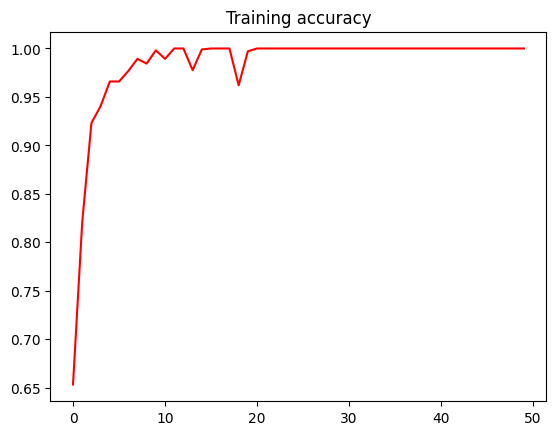

In [ ]:
acc = history.history['accuracy']

epochs = list(range(len(acc)))

plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.title('Training accuracy')
plt.show()

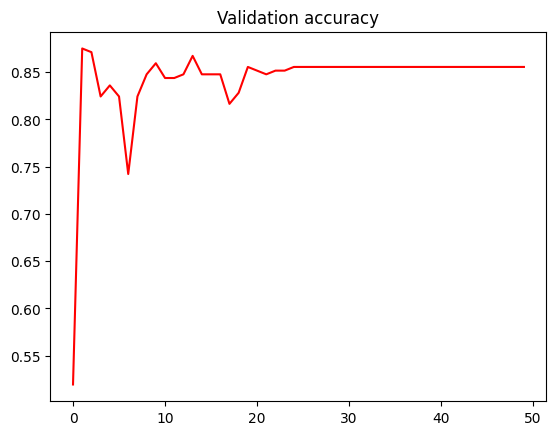

In [ ]:
val_acc = history.history['val_accuracy']

epochs = list(range(len(acc)))

plt.plot(epochs, val_acc, 'r', label='Validation accuracy')
plt.title('Validation accuracy')
plt.show()